In [1]:
# =============================================
# 🧠 Milestone 2: Medical Image Enhancement
# Project: AI-Powered Enhanced EHR Imaging & Documentation System
# =============================================

# Step 0: Imports and Setup
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from math import log10

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


In [3]:
# Step 1: Load Mapping Dataset from Milestone 1
mapping_path = r"C:\Users\A\Desktop\Internship\EHR_Infosys\data\mapping.csv"
output_dir = r"C:\Users\A\Desktop\Internship\EHR_Infosys\data\enhanced_images"
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(mapping_path)
print("📁 Mapping file loaded:", mapping_path)
print("Total records:", len(df))
df.head()


📁 Mapping file loaded: C:\Users\A\Desktop\Internship\EHR_Infosys\data\mapping.csv
Total records: 20000


,image_path,diagnosis,ehr_text
0,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,52
1,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,32
2,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,70
3,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,21
4,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,62


In [5]:
# Step 2: Define Enhancement Functions

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
def enhance_clahe(image):
    img_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
    enhanced = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)
    return enhanced

# Simple Denoising
def enhance_denoise(image):
    return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

print("✨ Enhancement functions ready!")


✨ Enhancement functions ready!


In [7]:
# Step 3: Apply Enhancement to Sample Images

sample_df = df.sample(10, random_state=42)
for i, row in sample_df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    enhanced = enhance_clahe(img)
    save_path = os.path.join(output_dir, os.path.basename(row["image_path"]))
    cv2.imwrite(save_path, enhanced)

print("✅ 10 sample images enhanced and saved at:", output_dir)


✅ 10 sample images enhanced and saved at: C:\Users\A\Desktop\Internship\EHR_Infosys\data\enhanced_images


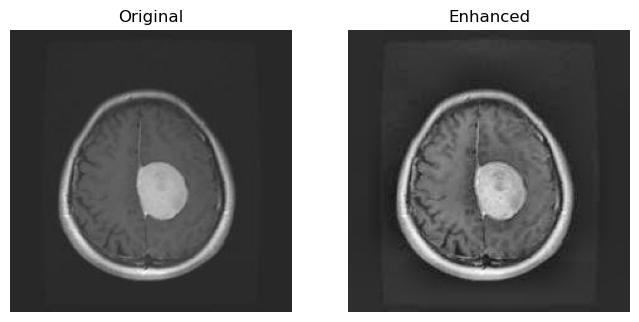

In [9]:
# Step 4: Visualize Before vs After Enhancement

def show_comparison(original_path, enhanced_path):
    orig = cv2.imread(original_path)
    enh = cv2.imread(enhanced_path)

    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    enh = cv2.cvtColor(enh, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(enh)
    plt.title("Enhanced")
    plt.axis("off")

    plt.show()

# Display first sample
show_comparison(sample_df.iloc[0]['image_path'],
                os.path.join(output_dir, os.path.basename(sample_df.iloc[0]['image_path'])))


In [ ]:
# Step 5: Evaluate Enhancement Quality (PSNR, SSIM)matrics

def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    return 20 * log10(255.0 / np.sqrt(mse))

psnr_scores, ssim_scores = [], []

for i, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    orig = cv2.imread(row["image_path"])
    enh = cv2.imread(os.path.join(output_dir, os.path.basename(row["image_path"])))

    if orig is None or enh is None:
        continue

    orig_gray = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
    enh_gray = cv2.cvtColor(enh, cv2.COLOR_BGR2GRAY)

    psnr_scores.append(psnr(orig_gray, enh_gray))
    ssim_scores.append(ssim(orig_gray, enh_gray))

metrics_df = pd.DataFrame({
    "image": sample_df["image_path"].apply(os.path.basename),
    "PSNR": psnr_scores,
    "SSIM": ssim_scores
})

print("📊 Enhancement Quality Metrics:")
display(metrics_df.head())
print("\nAverage PSNR:", np.mean(psnr_scores))
print("Average SSIM:", np.mean(ssim_scores))


100%|██████████| 10/10 [00:00<00:00, 16.62it/s]

📊 Enhancement Quality Metrics:


,image,PSNR,SSIM
10650,M_265_BR_.jpg,30.884330,0.918980
2041,N_363_DA_.jpg,29.682989,0.615480
8668,G_821.jpg,29.739005,0.668068
1114,N_243_VF_.jpg,28.085304,0.807041
13902,M_683_SP_.jpg,27.863376,0.627098



Average PSNR: 29.304050476044456
Average SSIM: 0.7190249800643216


In [13]:
# Step 6: Save Evaluation Results

metrics_path = os.path.join(output_dir, "enhancement_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("✅ Metrics saved to:", metrics_path)


✅ Metrics saved to: C:\Users\A\Desktop\Internship\EHR_Infosys\data\enhanced_images\enhancement_metrics.csv
